# Exploring YOLOv8 (Ultralytics)

Goal: load a pretrained YOLOv8n model (trained on COCO, 80 classes), run it on a sample image, and understand the output (`Results` object: boxes, classes, confidences).

Analogy: YOLO is like a friend who glances at a photo for one second and immediately points: "that's a dog at this spot, 92% sure; that's a person over there, 88% sure." One pass, all objects at once — hence "You Only Look Once".

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))  # so we can `from src...` import

from src.detector import load_model, predict
from src.utils import draw_detections

In [2]:
# Loads yolov8n.pt (auto-downloads to project root on first run, ~6MB)
model = load_model("../models/yolov8n.pt")

# COCO has 80 classes — e.g. person, car, dog, chair, etc.
print("Number of classes:", len(model.names))
print(model.names)

Number of classes: 80
{0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted plant', 59: 'bed', 60: 'dining table', 61: 'toilet', 62: 'tv', 63: 'laptop', 64: 'mouse', 65: 'remote', 66: 'keyboard', 67: 'ce

## Run inference on a sample image

Ultralytics ships sample images. We download one via the model's predict call on a URL, or use a local image from `../data/`.

In [3]:
image_path = "../data/bus.jpg"  # sample image (see data/ folder)

results = predict(model, image_path, conf=0.25)
result = results[0]

print("Boxes detected:", len(result.boxes))
for box in result.boxes:
    cls_id = int(box.cls[0])
    conf = float(box.conf[0])
    xyxy = box.xyxy[0].tolist()
    print(f"{result.names[cls_id]:<12} conf={conf:.2f}  box={xyxy}")

Boxes detected: 6
bus          conf=0.87  box=[22.871320724487305, 231.27734375, 805.0026245117188, 756.8404541015625]
person       conf=0.87  box=[48.55046463012695, 398.5522155761719, 245.34556579589844, 902.7026977539062]
person       conf=0.85  box=[669.472900390625, 392.1860656738281, 809.7201538085938, 877.0354614257812]
person       conf=0.83  box=[221.51730346679688, 405.7985534667969, 344.97064208984375, 857.53662109375]
person       conf=0.26  box=[0.0, 550.525146484375, 63.00693130493164, 873.44287109375]
stop sign    conf=0.26  box=[0.05815458297729492, 254.4593963623047, 32.55739974975586, 324.8741455078125]


## Visualize detections

Two ways: (1) ultralytics' built-in `.plot()`, or (2) our own `draw_detections()` from `src/utils.py` (used by the Streamlit app, so it's good to see it work here too).

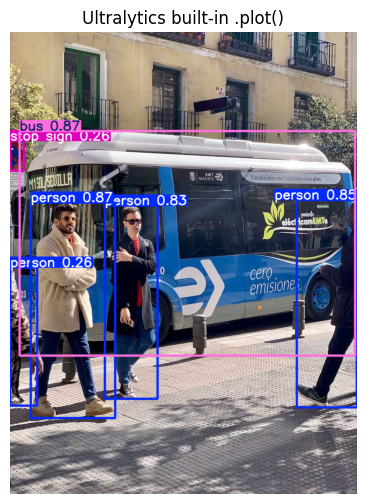

In [4]:
import cv2
import matplotlib.pyplot as plt

# Option 1: ultralytics built-in plotting
annotated_builtin = result.plot()  # returns BGR numpy array
plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(annotated_builtin, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Ultralytics built-in .plot()")
plt.show()

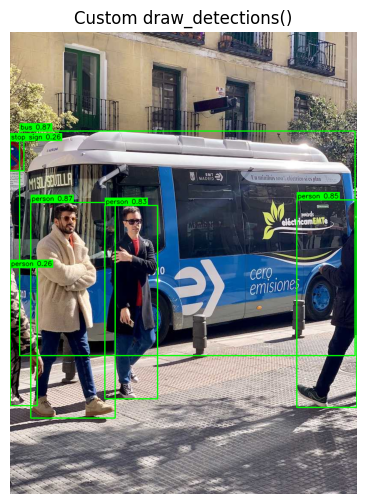

In [5]:
# Option 2: our own drawing function (same one the Streamlit app uses)
frame = cv2.imread(image_path)
annotated_custom = draw_detections(frame, result)

plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(annotated_custom, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Custom draw_detections()")
plt.show()

## Try a different confidence threshold

Lower `conf` -> more boxes (incl. less certain ones). Higher `conf` -> fewer, more confident boxes. Play with this to build intuition.

In [6]:
for conf_level in [0.1, 0.25, 0.5, 0.75]:
    r = predict(model, image_path, conf=conf_level)[0]
    print(f"conf={conf_level}: {len(r.boxes)} boxes detected")

conf=0.1: 6 boxes detected
conf=0.25: 6 boxes detected
conf=0.5: 4 boxes detected
conf=0.75: 4 boxes detected
